# 01 — M5 Exploratory Data Analysis

**Goal:** Build intuition for the M5 dataset before modelling. Key questions:
- What does the sales distribution look like? (Spoiler: heavily zero-inflated)
- How strong is weekly seasonality?
- Do categories behave differently?
- How does price vary across items?

**Data:** M5 Forecasting dataset, Store CA_1 (~3,049 SKUs × 1,941 days)

**Before running:** `make data-m5` from the repo root.

In [1]:
import sys
from pathlib import Path

# Make commerce_ml and forecasting importable without pip install
REPO_ROOT = Path("..").resolve().parent.parent
sys.path.insert(0, str(REPO_ROOT / "src"))  # commerce_ml
sys.path.insert(0, str(Path("..").resolve() / "src"))  # forecasting

import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from commerce_ml.viz.plotting import apply_style, PALETTE

apply_style()

RESULTS_DIR = Path("../results")
RESULTS_DIR.mkdir(exist_ok=True)

print("Setup complete.")

Matplotlib is building the font cache; this may take a moment.


Setup complete.


## 1. Load data

In [2]:
from forecasting.data import load_m5_long, zero_rate, aggregate_by_date

df = load_m5_long(store_id="CA_1")
print(f"Shape: {df.shape}")
print(f"Series (SKUs): {df['id'].nunique():,}")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")
print(f"Days: {df['date'].nunique()}")
df.head(3)

Shape: (5918109, 16)
Series (SKUs): 3,049
Date range: 2011-01-29 to 2016-05-22
Days: 1941


,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,date,wm_yr_wk,event_name_1,event_type_1,snap_CA,snap_TX,snap_WI,sell_price
0,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_1,3,2011-01-29,11101,NaN,NaN,0,0,0,2.0
1,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_2,0,2011-01-30,11101,NaN,NaN,0,0,0,2.0
2,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_3,0,2011-01-31,11101,NaN,NaN,0,0,0,2.0


In [7]:
print("=== Dataset overview ===")
print(f"Total rows:       {len(df):>12,}")
print(f"Unique SKUs:      {df['id'].nunique():>12,}")
print(f"Categories:       {df['cat_id'].unique()}")
print(f"Departments:      {df['dept_id'].nunique()} depts")
print()
print("=== Sales summary ===")
print(df["sales"].describe().apply(lambda x: format(round(x, 3), "f")).to_string())
print()
print(f"Zero-sales rate:  {zero_rate(df):.1%}")
print("  (60%+ is normal for daily SKU-level retail data)")

=== Dataset overview ===
Total rows:          5,918,109
Unique SKUs:             3,049
Categories:       <ArrowStringArray>
['FOODS', 'HOBBIES', 'HOUSEHOLD']
Length: 3, dtype: str
Departments:      7 depts

=== Sales summary ===
count    5918109.000000
mean           1.323000
std            4.052000
min            0.000000
25%            0.000000
50%            0.000000
75%            1.000000
max          648.000000

Zero-sales rate:  63.8%
  (60%+ is normal for daily SKU-level retail data)


## 2. Sales distribution

The distribution is heavily right-skewed with a large mass at zero.
This is normal for daily SKU-level retail: most items sell 0–2 units
on any given day, with occasional spikes.

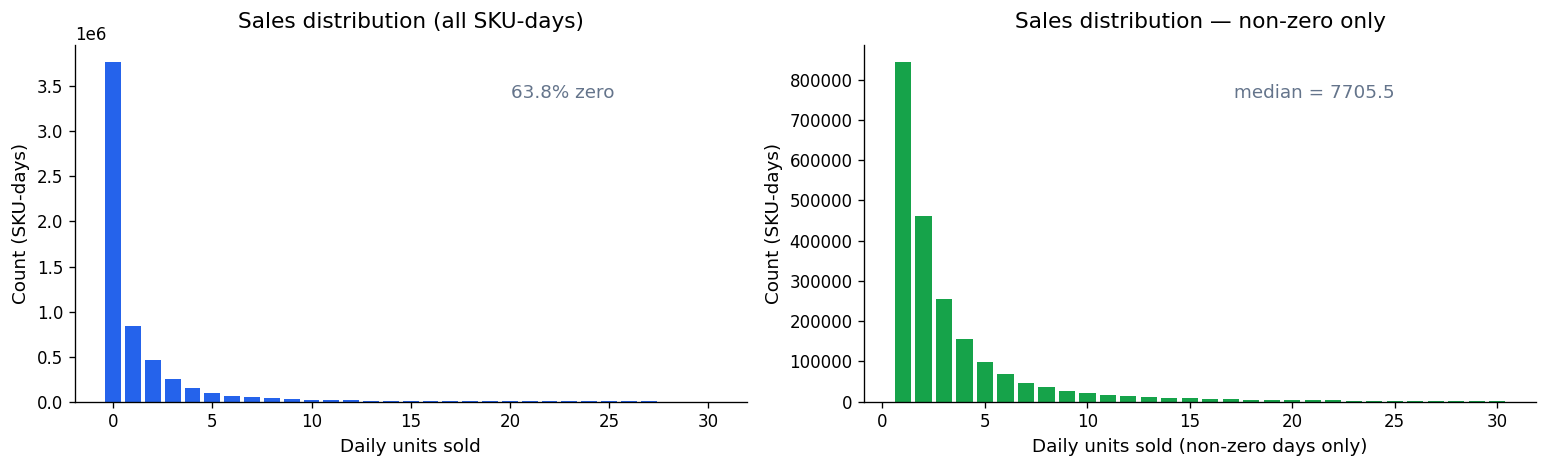

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: full distribution (including zeros)
ax = axes[0]
df_dist = df["sales"].value_counts().reset_index()
df_dist = df_dist[df_dist["sales"] <= 30]
ax.bar(df_dist["sales"], height=df_dist["count"], color=PALETTE[0])
ax.set_xlabel("Daily units sold")
ax.set_ylabel("Count (SKU-days)")
ax.set_title("Sales distribution (all SKU-days)")
ax.text(
    0.65, 0.85, f"{zero_rate(df):.1%} zero", transform=ax.transAxes, fontsize=11, color="#64748B"
)

# Right: non-zero only (to see the positive tail)
ax = axes[1]
nonzero = df_dist[df_dist["sales"] != 0]
ax.bar(nonzero["sales"], height=nonzero["count"], color=PALETTE[1])
ax.set_xlabel("Daily units sold (non-zero days only)")
ax.set_ylabel("Count (SKU-days)")
ax.set_title("Sales distribution — non-zero only")
ax.text(
    0.55,
    0.85,
    f"median = {nonzero['count'].median():.1f}",
    transform=ax.transAxes,
    fontsize=11,
    color="#64748B",
)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "eda_sales_distribution.png", dpi=150)
plt.show()

## 3. Zero-sales rate by category

Zero-sales rates vary a lot by category. High zero rates signal intermittent
demand — classical models (ARIMA, ETS) struggle here; tree-based models that
learn from the zero pattern tend to win.

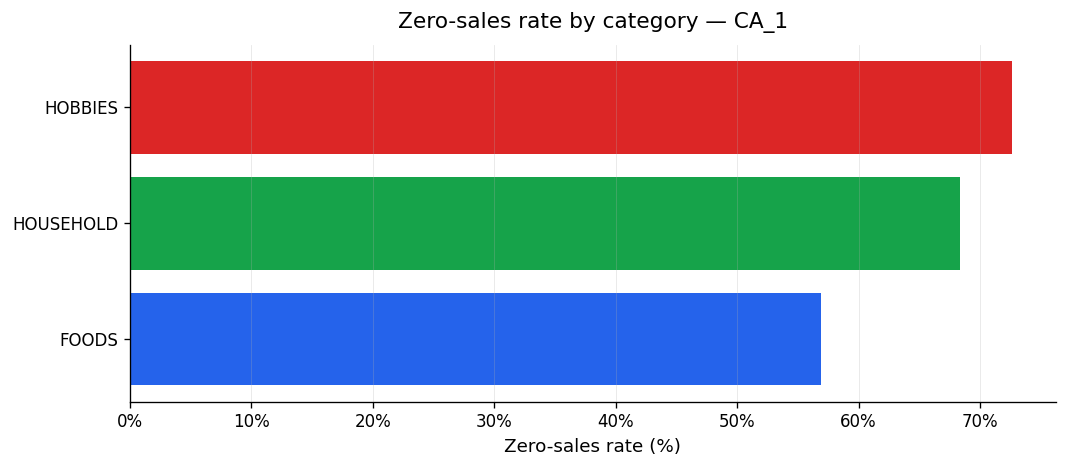

cat_id
FOODS        0.569186
HOUSEHOLD    0.683663
HOBBIES      0.726190


In [43]:
zero_by_cat = (
    df.groupby("cat_id")
    .apply(lambda g: (g["sales"] == 0).mean())
    .sort_values(ascending=True)
    .rename("zero_rate")
)

fig, ax = plt.subplots(figsize=(9, 4))
colors = [PALETTE[i % len(PALETTE)] for i in range(len(zero_by_cat))]
ax.barh(zero_by_cat.index, zero_by_cat.values * 100, color=colors)
ax.set_xlabel("Zero-sales rate (%)")
ax.set_title("Zero-sales rate by category — CA_1")
ax.xaxis.set_major_formatter(mticker.PercentFormatter())
ax.grid(axis="x")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "eda_zero_rate_by_category.png", dpi=150)
plt.show()

print(zero_by_cat.to_string())

## 4. Total store sales over time

Aggregating across all SKUs smooths the zero-inflation and reveals macro trends:
growth, annual seasonality, and weekly rhythm.

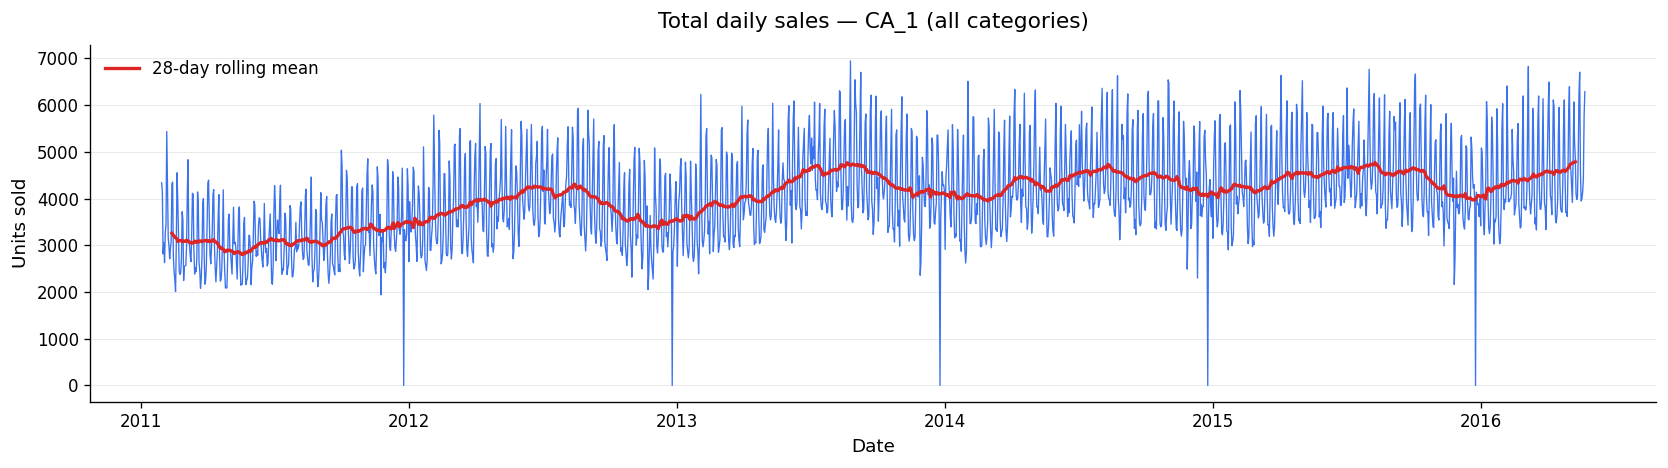

In [45]:
daily_total = aggregate_by_date(df)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(daily_total["date"], daily_total["sales"], color=PALETTE[0], linewidth=0.8, alpha=0.9)

# 28-day rolling mean overlay
rolling = daily_total["sales"].rolling(28, center=True).mean()
ax.plot(daily_total["date"], rolling, color=PALETTE[2], linewidth=2, label="28-day rolling mean")

ax.set_title("Total daily sales — CA_1 (all categories)")
ax.set_xlabel("Date")
ax.set_ylabel("Units sold")
ax.legend()
ax.grid(axis="y")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "eda_total_sales_over_time.png", dpi=150)
plt.show()

## 5. Weekly seasonality

Retail has strong day-of-week patterns. This is the primary reason
`SeasonalNaive(m=7)` outperforms plain naive. A global LightGBM model
will capture this via lag-7 features and Fourier terms.

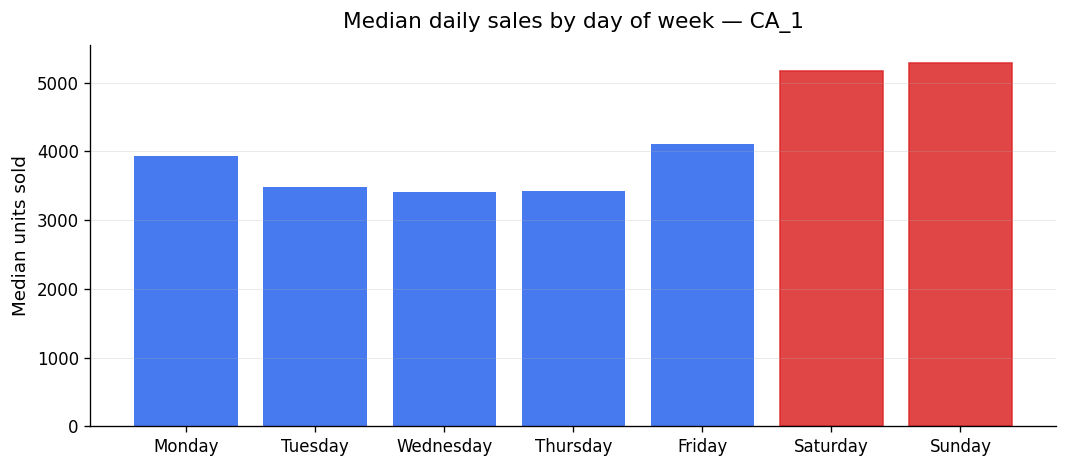

Weekend lift over weekday mean: +42.2%


In [46]:
daily_total["dow"] = daily_total["date"].dt.day_name()
dow_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

dow_median = daily_total.groupby("dow")["sales"].median().reindex(dow_order)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(dow_order, dow_median.values, color=PALETTE[0], alpha=0.85)

# Highlight weekend
for i, day in enumerate(dow_order):
    if day in ("Saturday", "Sunday"):
        bars[i].set_color(PALETTE[2])

ax.set_title("Median daily sales by day of week — CA_1")
ax.set_ylabel("Median units sold")
ax.grid(axis="y")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "eda_weekly_seasonality.png", dpi=150)
plt.show()

weekend_lift = (
    dow_median[["Saturday", "Sunday"]].mean()
    / dow_median[["Monday", "Tuesday", "Wednesday", "Thursday", "Friday"]].mean()
    - 1
)
print(f"Weekend lift over weekday mean: {weekend_lift:+.1%}")

## 6. Category-level trends

Different categories have different demand profiles. FOODS dominates volume;
HOBBIES has the highest zero-rate; HOUSEHOLD is most stable.

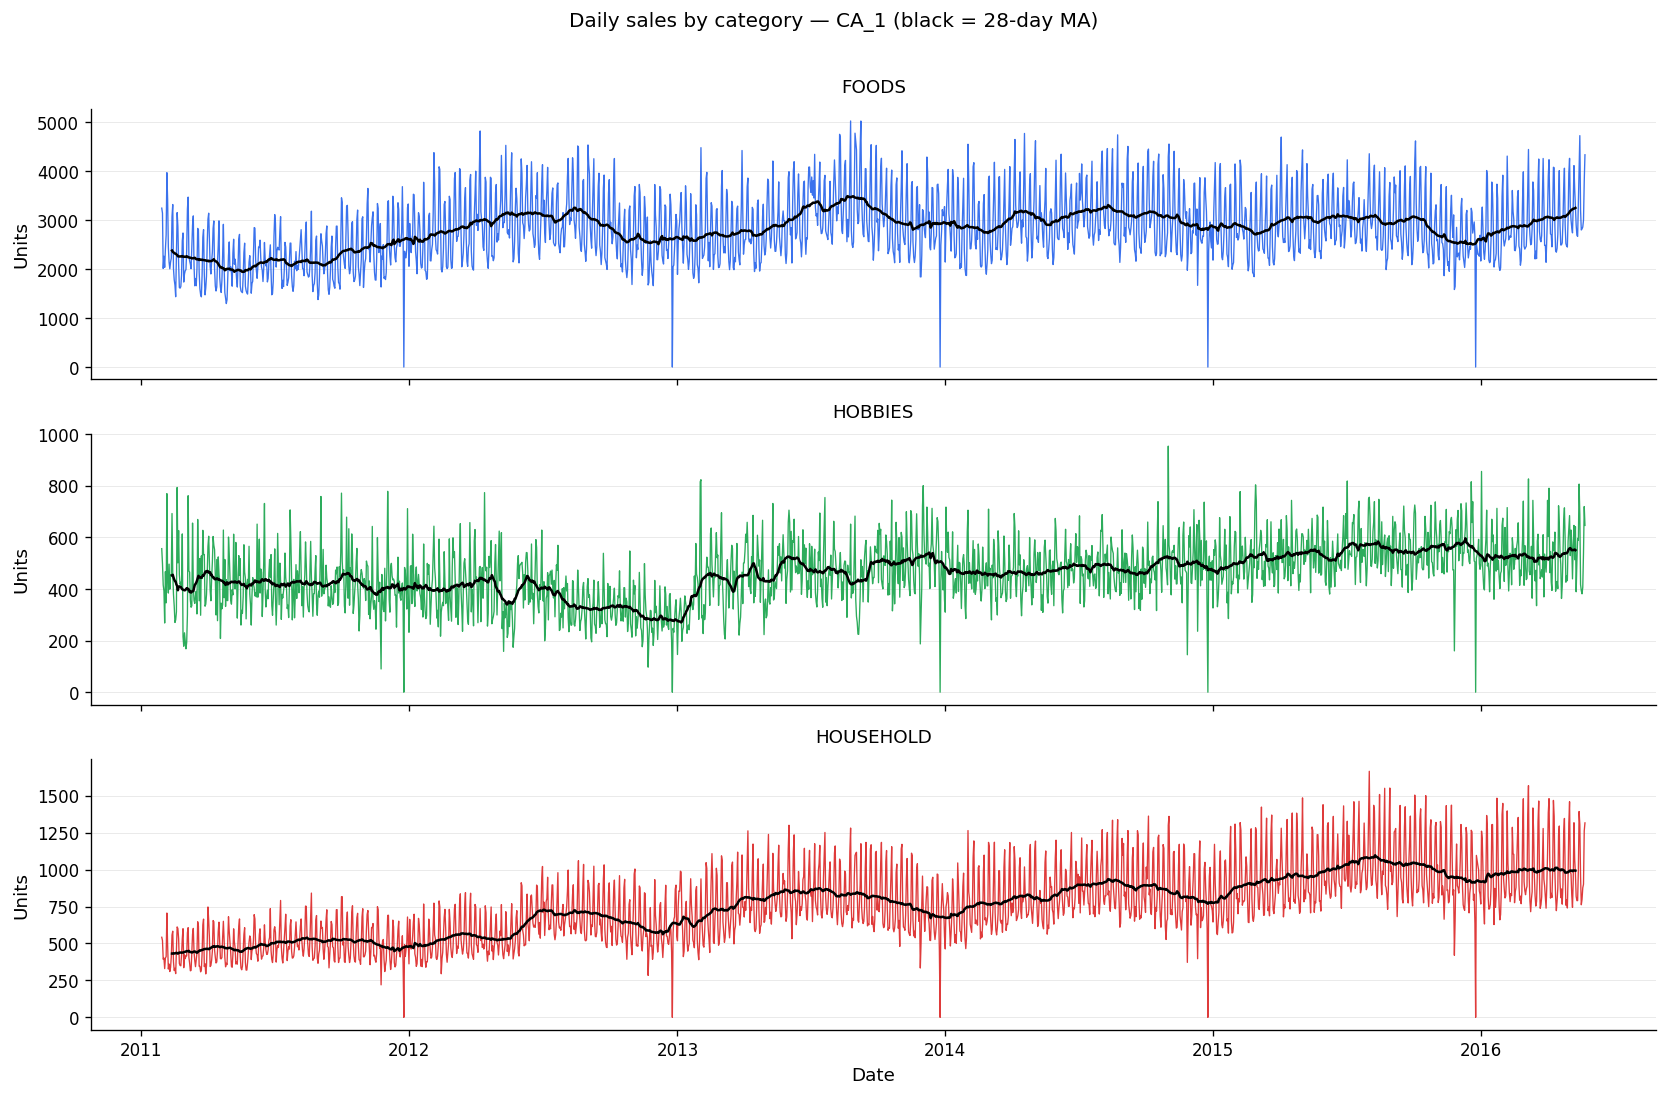

In [47]:
cat_daily = aggregate_by_date(df, group_col="cat_id")
categories = cat_daily["cat_id"].unique()

fig, axes = plt.subplots(len(categories), 1, figsize=(14, 3 * len(categories)), sharex=True)

for i, cat in enumerate(sorted(categories)):
    ax = axes[i]
    subset = cat_daily[cat_daily["cat_id"] == cat]
    ax.plot(
        subset["date"], subset["sales"], color=PALETTE[i % len(PALETTE)], linewidth=0.8, alpha=0.9
    )
    rolling = subset["sales"].rolling(28, center=True).mean()
    ax.plot(subset["date"], rolling, color="black", linewidth=1.5)
    ax.set_title(f"{cat}", fontsize=11)
    ax.set_ylabel("Units")
    ax.grid(axis="y")

axes[-1].set_xlabel("Date")
fig.suptitle("Daily sales by category — CA_1 (black = 28-day MA)", y=1.01)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "eda_category_trends.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Sample SKU time series

Zooming in on individual SKUs reveals the challenge: many series are
intermittent (lots of zeros) with occasional demand spikes. A single
global model needs to handle all of these patterns.

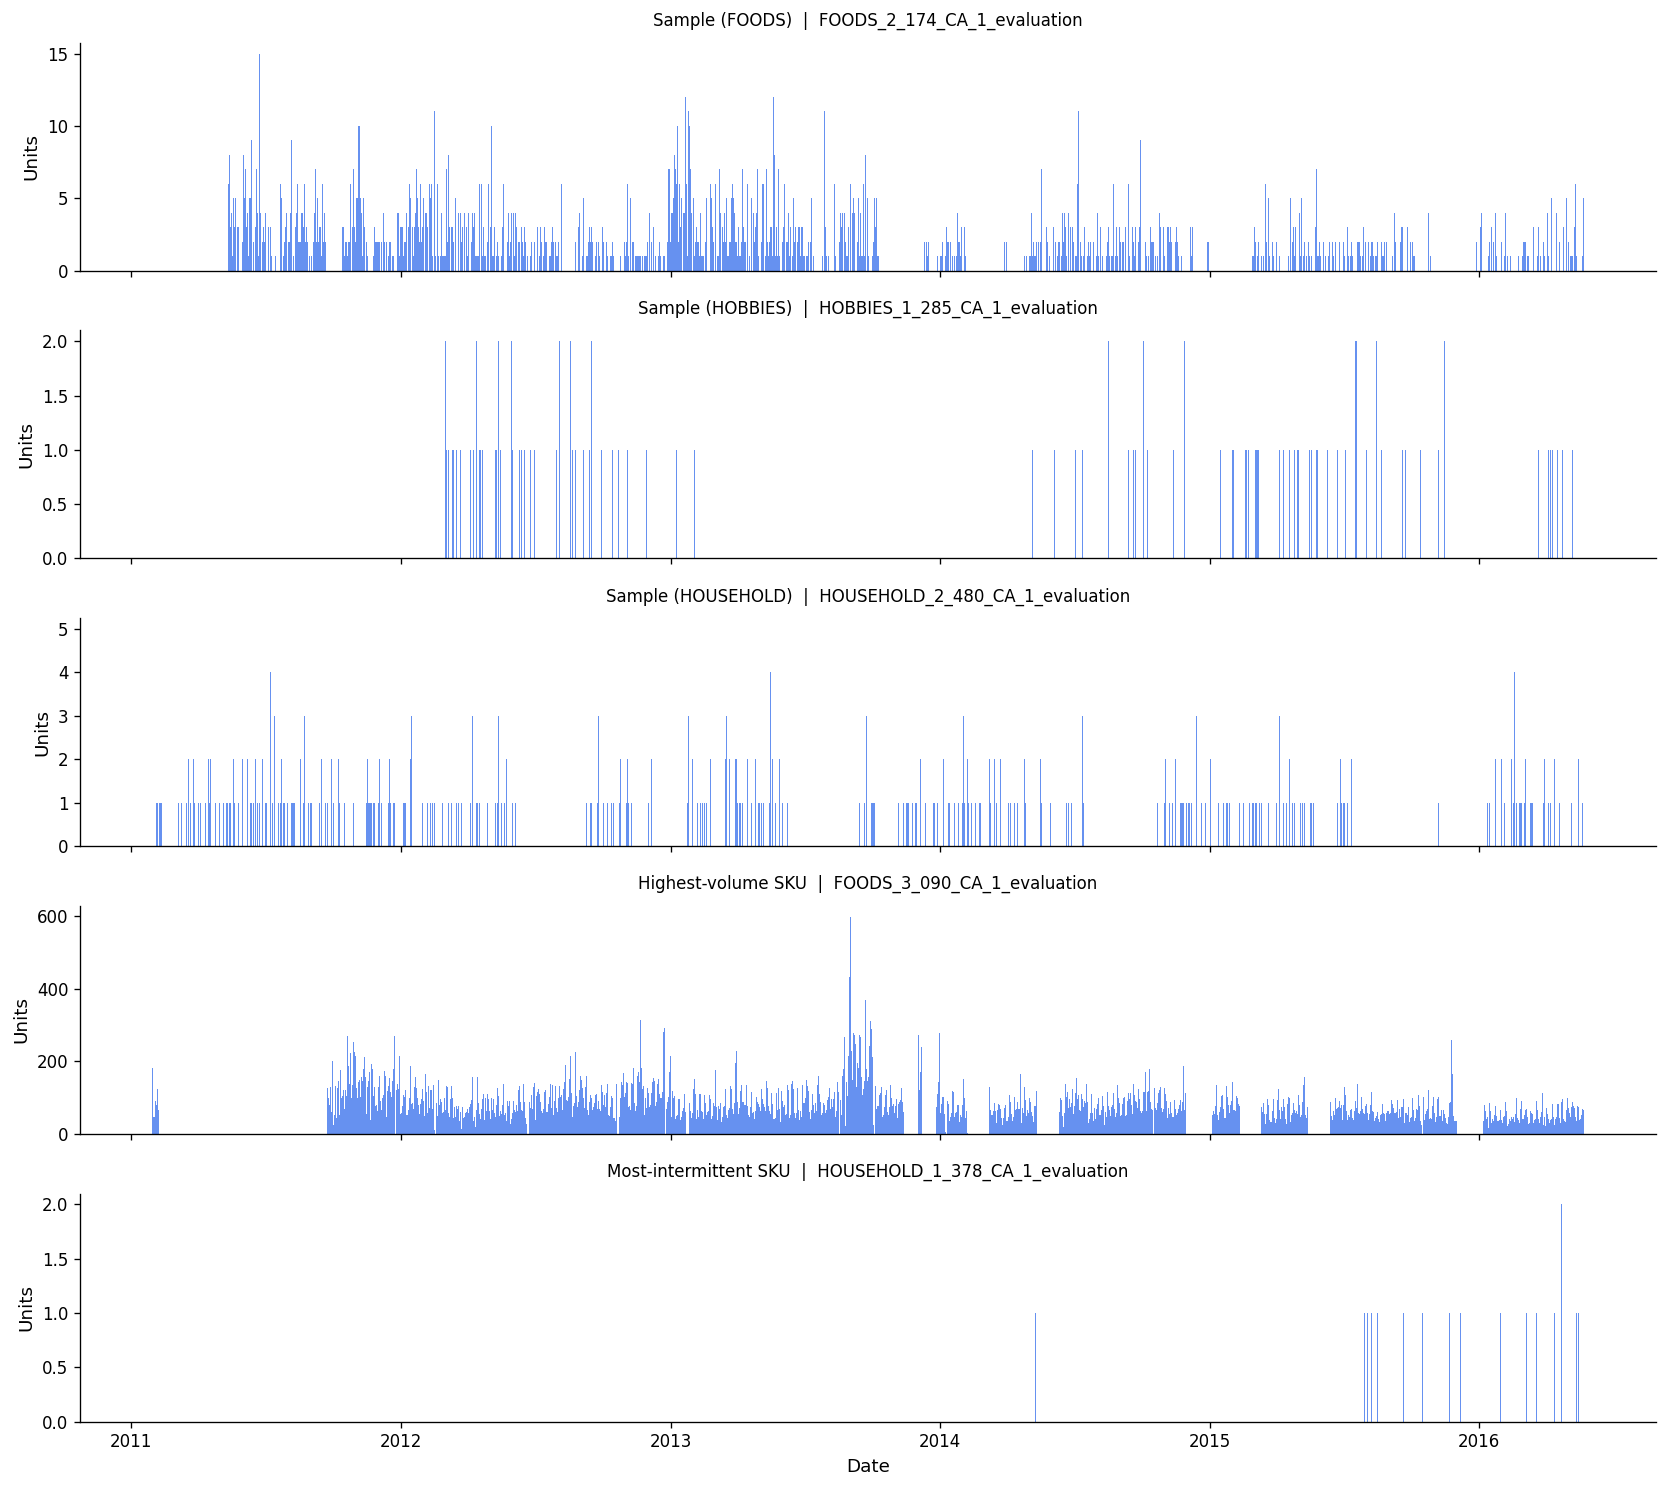

In [48]:
# Sample one SKU per category
np.random.seed(42)
sample_ids = df.groupby("cat_id").apply(lambda g: g["id"].sample(1).iloc[0]).values

# Add one high-volume and one intermittent series for contrast
top_sku = df.groupby("id")["sales"].sum().idxmax()
sparse_sku = (
    df.groupby("id").apply(lambda g: (g["sales"] == 0).mean()).sort_values(ascending=False).index[0]
)

show_ids = list(sample_ids) + [top_sku, sparse_sku]
labels = [f"Sample ({cat})" for cat in sorted(df["cat_id"].unique())] + [
    "Highest-volume SKU",
    "Most-intermittent SKU",
]

fig, axes = plt.subplots(len(show_ids), 1, figsize=(14, 2.5 * len(show_ids)), sharex=True)

for ax, sku, label in zip(axes, show_ids, labels):
    s = df[df["id"] == sku].sort_values("date")
    ax.bar(s["date"], s["sales"], width=1.0, color=PALETTE[0], alpha=0.7)
    ax.set_title(f"{label}  |  {sku}", fontsize=10)
    ax.set_ylabel("Units")

axes[-1].set_xlabel("Date")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "eda_sample_sku_series.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Price distribution

Price is an important feature for the LightGBM model — promotions and
markdowns affect demand directly. We'll engineer price-change features
(is this week cheaper than last week?) for the ML model.

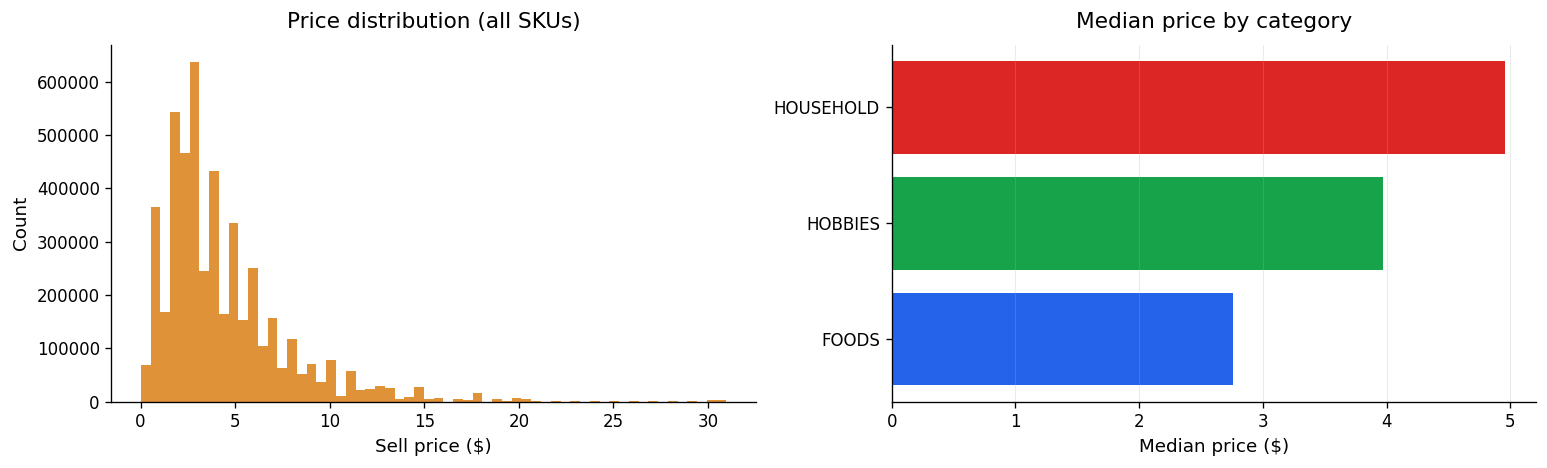

Price summary by category:
               count  mean   std   min   25%   50%   75%    max
cat_id                                                         
FOODS      2260241.0  3.29  2.14  0.20  1.98  2.76  3.98  19.48
HOBBIES     888758.0  5.32  4.85  0.05  1.97  3.97  7.44  30.98
HOUSEHOLD  1639268.0  5.47  3.37  0.01  2.98  4.96  6.97  29.97


In [49]:
# Drop NaN prices (items not yet listed at that date)
prices = df.dropna(subset=["sell_price"])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.hist(prices["sell_price"], bins=60, color=PALETTE[3], alpha=0.8)
ax.set_xlabel("Sell price ($)")
ax.set_ylabel("Count")
ax.set_title("Price distribution (all SKUs)")

ax = axes[1]
price_by_cat = prices.groupby("cat_id")["sell_price"].median().sort_values()
ax.barh(
    price_by_cat.index, price_by_cat.values, color=[PALETTE[i] for i in range(len(price_by_cat))]
)
ax.set_xlabel("Median price ($)")
ax.set_title("Median price by category")
ax.grid(axis="x")

plt.tight_layout()
plt.savefig(RESULTS_DIR / "eda_price_distribution.png", dpi=150)
plt.show()

print("Price summary by category:")
print(prices.groupby("cat_id")["sell_price"].describe().round(2).to_string())

## 9. Summary & implications for modelling

Key findings:

| Finding | Modelling implication |
|---------|----------------------|
| ~62% zero-sales days | WMAPE over MAPE; tree models handle zeros natively |
| Strong weekly seasonality | Include lag-7, lag-14 features; seasonal naive is a strong baseline |
| Categories differ in zero-rate | Category as a feature in the global model |
| Price varies across items | Include sell_price and price-change features |
| Right-skewed sales distribution | Don't use RMSE as the primary loss (MSE penalises high-demand outliers) |

**Next notebook:** `02_baselines.ipynb` — establish the floor every model must beat.

In [50]:
# Save key EDA stats to results
eda_summary = pd.DataFrame(
    {
        "metric": [
            "n_series",
            "n_days",
            "zero_rate",
            "median_nonzero_sales",
            "date_min",
            "date_max",
        ],
        "value": [
            df["id"].nunique(),
            df["date"].nunique(),
            f"{zero_rate(df):.3f}",
            df.loc[df["sales"] > 0, "sales"].median(),
            str(df["date"].min().date()),
            str(df["date"].max().date()),
        ],
    }
)
eda_summary.to_csv(RESULTS_DIR / "eda_summary.csv", index=False)
print("Saved EDA summary to results/eda_summary.csv")
print(eda_summary.to_string(index=False))

Saved EDA summary to results/eda_summary.csv
              metric      value
            n_series       3049
              n_days       1941
           zero_rate      0.638
median_nonzero_sales        2.0
            date_min 2011-01-29
            date_max 2016-05-22
